In [1]:
import sys
sys.path.insert(0,'/nfs/nfs2/users/riadoshi/bigvision_palivla/')
sys.path.insert(0, '/nfs/nfs2/users/riadoshi/bigvision_palivla/src/')
sys.path.insert(0,'/nfs/nfs2/users/riadoshi/bigvision_palivla/dlimp')
sys.path.insert(0,'/nfs/nfs2/users/riadoshi/bigvision_palivla/models')

import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

import tensorflow as tf
tf.config.set_visible_devices([], "GPU")

import jax
import jax.experimental.multihost_utils as mhu
from jax.experimental import multihost_utils

from absl import flags
import optax
import numpy as np
import orbax.checkpoint as ocp
from transformers import AutoTokenizer
import mediapy
from ml_collections import config_flags
from typing import Any

from scalax.sharding import MeshShardingHelper, FSDPShardingRule

from palivla.components.train_state import ShardingMetadata
from palivla.model_components import ModelComponents
from octo.data.utils.data_utils import NormalizationType

from palivla.dataset import make_trajectory_dataset
import palivla
from palivla.components.sequence_builder import SequenceBuilder

from scripts.train import create_model

from big_vision.utils import Registry

from octo.data.oxe import make_oxe_dataset_kwargs
from octo.data.dataset import make_single_dataset

import importlib

2025-04-11 18:14:54.841755: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-11 18:14:54.845043: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-11 18:14:54.856045: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744395294.874841  237592 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744395294.880570  237592 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744395294.894054  237592 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
# Reset flags if the cell is re-run
try:
    flags.FLAGS.unparse_flags()
except AttributeError:
    flags.FLAGS._flag_values_dict.clear()

# Define the config flag only if it hasn't been defined
if "config" not in flags.FLAGS:
    config_flags.DEFINE_config_file(
        "config", "/nfs/nfs2/users/riadoshi/bigvision_palivla/configs/cot_all.py", "Path to the config file."
    )

import sys
flags.FLAGS(sys.argv, known_only=True)

config = flags.FLAGS.config

In [3]:
# MODEL_PATH, MODEL_STEP = 'gs://kyle-checkpoints-c2/paligemma-checkpoints/solar-feather-24', 40000
# MODEL_PATH, MODEL_STEP = 'gs://multi-robot-bucket3/runs/vla/cot_all_07042025_075319', 140000
MODEL_PATH, MODEL_STEP = "gs://multi-robot-bucket3/runs/vla/cot_all_11042025_005024", 70000

mesh = MeshShardingHelper([-1], ["fsdp"])
sharding_metadata = ShardingMetadata(
    mesh=mesh,
    model_sharding_rule=FSDPShardingRule(
        "fsdp", fsdp_axis_size=mesh.mesh.shape["fsdp"]
    ),
)

optimizer = optax.identity()
print("Loading model params...")

model = create_model(config, sharding_metadata)
for load_fn, load_fn_kwargs in config.load_fns:
    load_fn = Registry.lookup(load_fn)
    load_fn(model, **load_fn_kwargs)

restore_manager = ocp.CheckpointManager(
    MODEL_PATH, options=ocp.CheckpointManagerOptions()
)
model.load_state(MODEL_STEP, restore_manager)
train_state = model.train_state

Loading model params...


tokenizer_config.json:   0%|          | 0.00/243k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/34.6M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/253 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/3.00 [00:00<?, ?B/s]

Some kwargs in processor config are unused and will not have any effect: time_horizon, vocab_size, scale, action_dim, min_token. 


paligemma-3b-mix-224.npz:   0%|          | 0.00/11.7G [00:00<?, ?B/s]

Replacing param /llm/embedder/input_embedding with subarray strategy


I0411 18:17:36.523253  239695 google_auth_provider.cc:181] Running on GCE, using service account 180902422847-compute@developer.gserviceaccount.com


In [12]:
viz_kwargs = config.visualization_datasets['aloha_pick_place_full_dataset'].to_dict()
viz_kwargs['data_dir'] = 'gs://rail-orca-central2/resize_256_256/'
viz_kwargs['use_cot'] = True
viz_kwargs['cot_data_path'] = 'gs://multi-robot-bucket2/data/generated_data'
# viz_kwargs = {'action_proprio_normalization_type': NormalizationType.NORMAL,
#  'cot_data_path': None,
#  'data_dir': 'gs://rail-orca-central2/resize_256_256/',
#  'force_recompute_dataset_statistics': False,
#  'frame_transform_kwargs': {'image_augment_kwargs': {},
#   'resize_size': {'high': [224, 224]}},
#  'load_camera_views': ['high'],
#  'load_depth': False,
#  'load_language': True,
#  'load_proprio': True,
#  'name': 'aloha_pen_uncap_diverse_dataset',
#  'use_cot': False}
viz_dataset =  make_trajectory_dataset(**viz_kwargs,train=True)
viz_dataset_iterator = viz_dataset.iterator()



loading cot data
loaded cot data!
building the reasoning dict...


reasoning dict: 100%|██████████| 733/733 [00:21<00:00, 33.44it/s]


Example reasoning: 0_0 right-end-effector<loc0700><loc0726>;shrimp<loc0760><loc0552><loc0788><loc0584>;grey bowl<loc0608><loc0408><loc0708><loc0476>;right-end-effector<loc0706><loc0680>;right-end-effector<loc0706><loc0651>;right-end-effector<loc0734><loc0622>;right-end-effector<loc0737><loc0593>;shrimp<loc0764><loc0524><loc0788><loc0564>;
Reasoning presence statistics [# has not, # has]: [0, 733]
Reasoning lengths: mean 269.0137835379718, min 0, max 650, p99 479.0, p99.9 538.0


In [13]:
viz_trajectories = [next(viz_dataset_iterator) for _ in range(25)]
# for t in viz_trajectories:
#     t['observation']['image_primary'] = t['observation']['image_high']
#     t['observation']['pad_mask_dict']['image_primary'] = t['observation']['pad_mask_dict']['image_high']
#     t['observation'].pop('image_high')
#     t['observation'].pop('proprio_bimanual')

In [18]:
from palivla.visualizations.chain_of_thought import parse_cot_string, visualize_trajectory, TrajectoryData
import matplotlib.pyplot as plt
import io
from PIL import Image


def create_viz(
    image: np.ndarray,
    pred_trajectory: TrajectoryData,
    target_trajectory: TrajectoryData,
    prompt_str: str,
) -> np.ndarray:
    """Create a side-by-side visualization comparing predicted and target trajectories.

    Args:
        image: Input image to show in both panels
        pred_trajectory: Predicted trajectory from the model
        target_trajectory: Target/ground truth trajectory
        prompt_str: Text prompt to show as subtitle

    Returns:
        PIL Image containing the rendered figure
    """
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Remove <pad> from prompt string
    prompt_str = prompt_str.replace("<pad>", "")
    fig.suptitle(prompt_str, wrap=True)

    # Plot predicted and target trajectories
    visualize_trajectory(ax1, image, pred_trajectory, "Predicted")
    visualize_trajectory(ax2, image, target_trajectory, "Target")

    # Adjust layout and convert to image
    plt.tight_layout()

    # Convert figure to PIL Image
    buf = io.BytesIO()
    plt.savefig(buf, format="png")
    buf.seek(0)
    img = Image.open(buf)
    plt.close(fig)

    return img

def chain_of_thought(model, trajectory):
    frame = jax.tree_map(lambda x: x[100:101], trajectory)
    frame["observation"] = jax.tree_map(lambda x: x[None], frame["observation"])
    frame["action"] = trajectory["action"][None, :4, :]

    # Predict chain-of-thought
    sequences = model.build_sequence(frame, begin_is_prompt=True)
    # print("sequence: ", sequences['gen'])
    viz_batch, sequences = mhu.broadcast_one_to_all(
        ({"observation": frame["observation"]}, sequences)
    )
    predicted_tokens = model.predict_tokens(
        viz_batch, sequences, use_ema_params=False, replicate=True
    )

    # Decode the tokens
    predicted_text_tokens = np.array(
        [model.language_tokenizer.decode(tok) for tok in predicted_tokens[0]]
    )

    target_gen_tokens = sequences["gen"]["tokens"]
    target_gen_text_tokens = np.array(
        [model.language_tokenizer.decode(tok) for tok in target_gen_tokens[0]]
    )

    prompt_tokens = sequences["prompt"]["tokens"]
    prompt_text_tokens = np.array(
        [
            model.language_tokenizer.decode(tok)
            for tok in prompt_tokens[0]
            if tok != "<pad>"
        ]
    )
    # print(prompt_text_tokens)

    # Get action start indices
    pred_action_start_idxs = (
        np.argwhere(predicted_text_tokens == "<begin_of_action>") + 1
    )
    pred_action_start_idx = (
        np.min(pred_action_start_idxs) if pred_action_start_idxs.size > 0 else -1
    )
    target_action_start_idx = (
        np.min(np.argwhere(target_gen_text_tokens == "<begin_of_action>")) + 1
    )

    # print("gt: ", sequences['gen']['tokens'])
    # print("pred: ", predicted_text_tokens[pred_action_start_idx:])

    # if 'palivla.components.sequence_builder' in sys.modules:
    #     del sys.modules['palivla.components.sequence_builder']
    # importlib.reload(sequence_builder)

    sequence_builder = SequenceBuilder(
        prompt_pad_length=50, 
        gen_pad_length=150,
        action_chunk_pad_length=4
    )

    actions, actions_mask = sequence_builder.batch_get_actions(
            predicted_tokens,
            model.language_tokenizer,
            model.action_tokenizer,
            begin_is_prompt=True,
            action_dim=14,
            action_chunk_sizes=[4],
    )
    
    # Concatenate tokens into strings
    prompt_str = "".join(prompt_text_tokens)
    pred_cot_str = "".join(predicted_text_tokens[:pred_action_start_idx])
    target_cot_str = "".join(target_gen_text_tokens[:target_action_start_idx])

    # Parse both predicted chain of thought string
    pred_trajectory = parse_cot_string(pred_cot_str)
    target_trajectory = parse_cot_string(target_cot_str)

    # Create side-by-side visualization
    image = frame["observation"]['image_primary'].squeeze()
    comparison_image = create_viz(
        image, pred_trajectory, target_trajectory, prompt_str
    ) # this is just gonna be predicted trajectory twice

    return comparison_image, actions



4
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])


/tmp/ipykernel_237592/972617935.py:48: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  frame = jax.tree_map(lambda x: x[100:101], trajectory)
/tmp/ipykernel_237592/972617935.py:49: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  frame["observation"] = jax.tree_map(lambda x: x[None], frame["observation"])


Error decoding tokens: Decoded DCT coefficients have shape (50, 14), expected (4, 14)
Tokens: [ 393  272  321  363  295  391  982  344  384 1196  321  334  258  593
  280  328  453  573  282  316  515  582  346  456  261  350  471  261
  576  312  274  261  350  471  261  349  456  262  392  343  261  573
  312  267]
(224, 224, 3)
(224, 224, 3)
[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


""

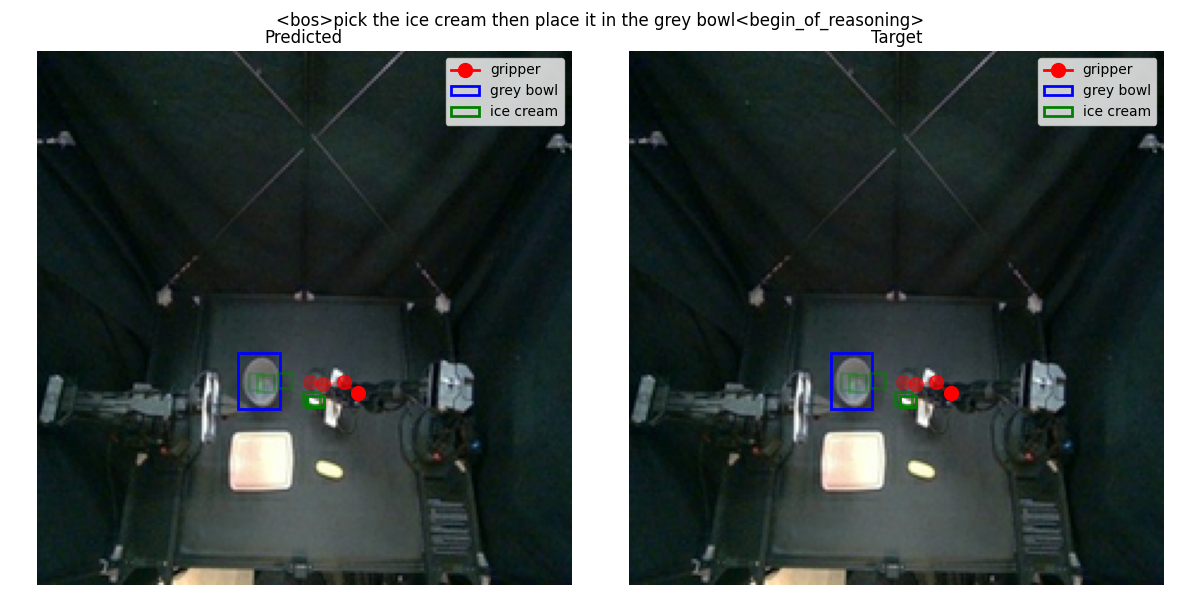

1
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
Error decoding tokens: Decoded DCT coefficients have shape (50, 14), expected (4, 14)
Tokens: [ 376  319  317 1922  652  464  339  304  309  443  384  344  362  362
  340  282 1074  278  353  274  311  521 1063  488  657  392  395  360
  279 1219  260]
(224, 224, 3)
(224, 224, 3)
[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


""

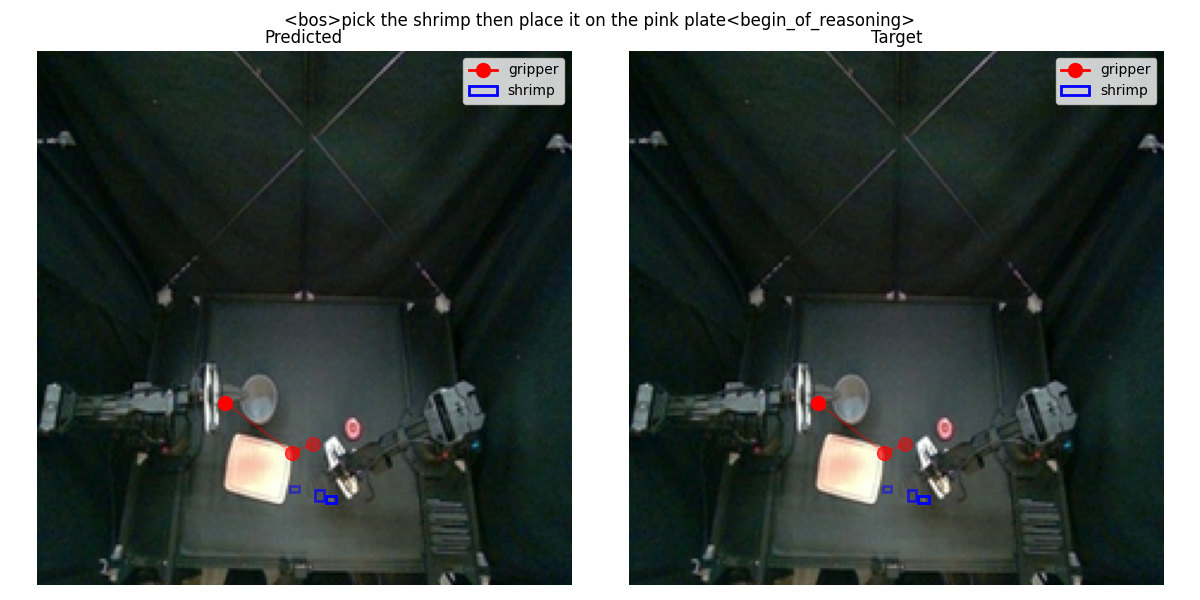

19
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
Error decoding tokens: Decoded DCT coefficients have shape (50, 14), expected (4, 14)
Tokens: [ 409 1311  335  404  429  263  225  319  291  322  557  547  377  266
 1016  310  310 1513 1047  279 1681  273  420  794  286  438  360  340
  286  311  534  311  456  840  456  471  261  350  312  539  343  471
  312  273  342  261  576  456  343  264  276]
(224, 224, 3)
(224, 224, 3)
[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


""

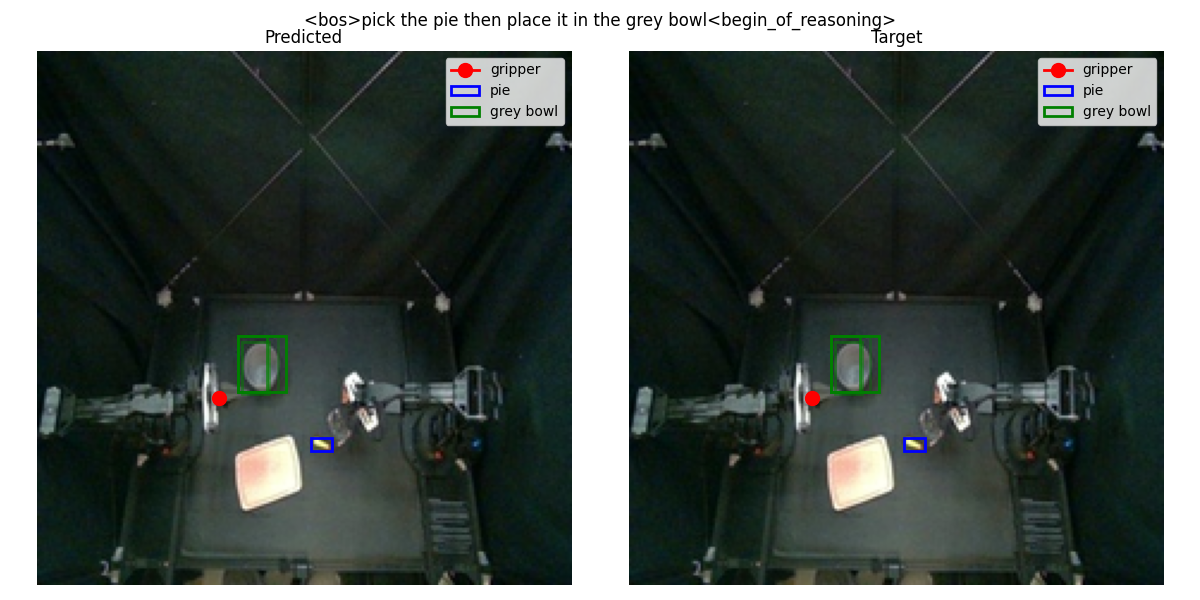

23
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
Error decoding tokens: Decoded DCT coefficients have shape (50, 14), expected (4, 14)
Tokens: [ 422  299  304 1059  583  341  328  364  996  334  273  268  245  665
  291  314  394  274  258  438  310  522 1638  844  525 1040  392  822
  278  834  355  601 1219  257]
(224, 224, 3)
(224, 224, 3)
[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


""

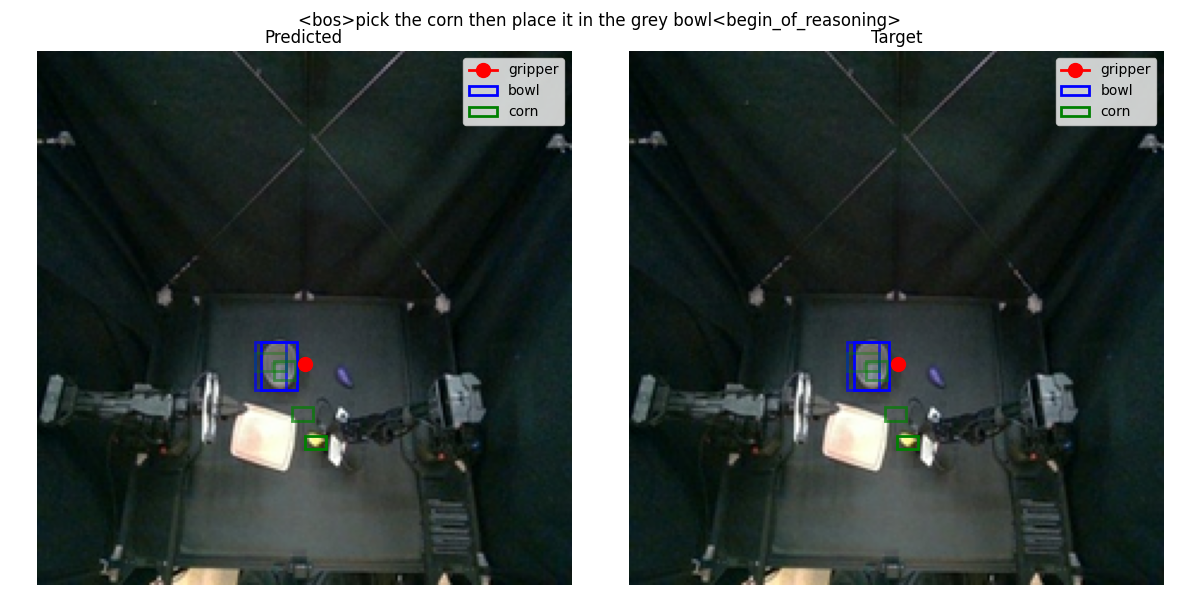

16
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
Error decoding tokens: Decoded DCT coefficients have shape (50, 14), expected (4, 14)
Tokens: [ 372  303  447  412  317  391  266  409 1433  335  495  697  371  291
  292  549  300  978  273  375  641 1016  293  602  524 1612  279  292
  881  326  324 1646  274  681  274  287  353 1245  360  292 1245  416
  456  471  840  342  261  576  312  273  270  349  262  381  305]
(224, 224, 3)
(224, 224, 3)
[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


""

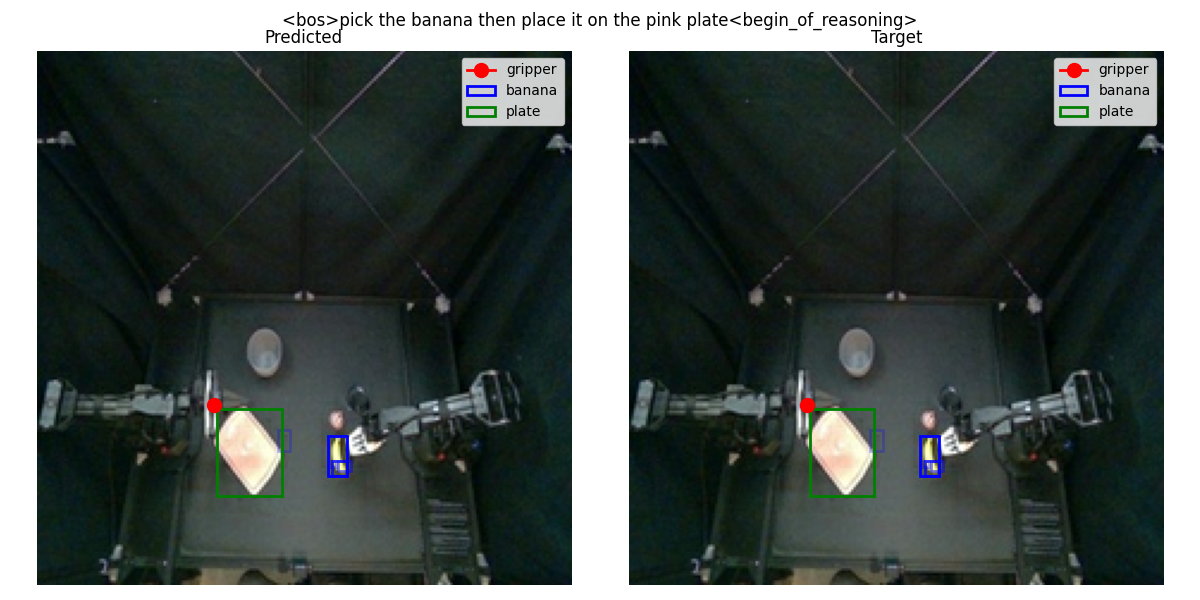

3
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
Error decoding tokens: Decoded DCT coefficients have shape (50, 14), expected (4, 14)
Tokens: [422 265 462 291 418 445 266 429 334 280 429 334 321 363 380 293 358 310
 440 356 380 293 310 297 515 273 311 292 483 392 273 286 530 274 534 456
 471 471 343 262 383 342 262 383 261 349 261 576 471 343 261 350 471 343
 262 392 261 258]
(224, 224, 3)
(224, 224, 3)
[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


""

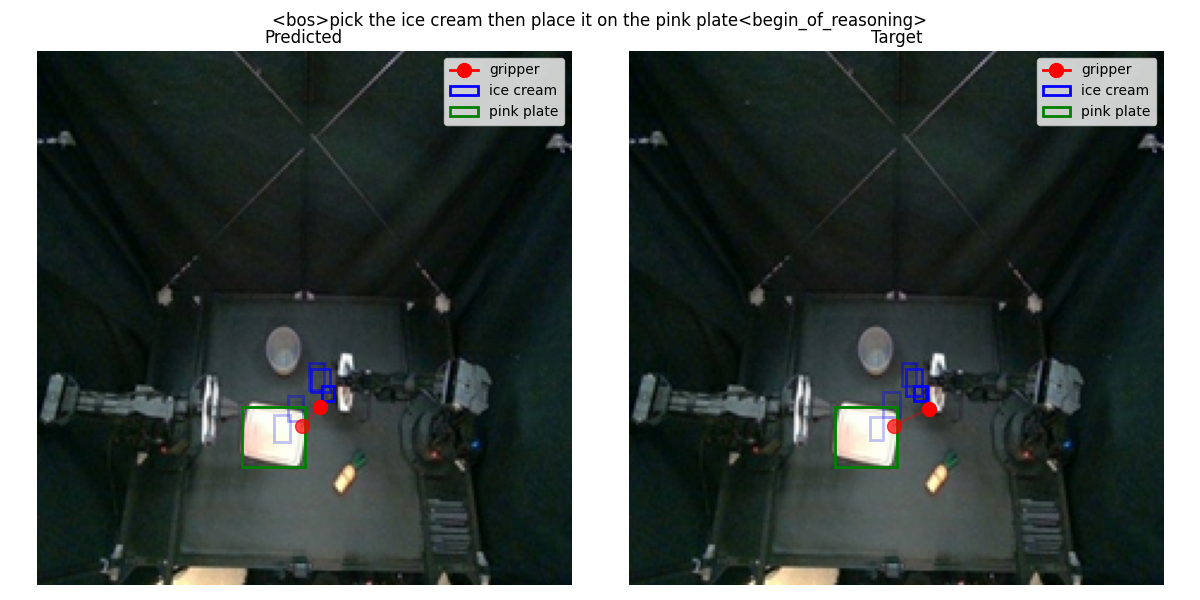

12
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
Error decoding tokens: Decoded DCT coefficients have shape (50, 14), expected (4, 14)
Tokens: [ 300  609  339  304  351  266  373  334  373  300  319  309  328  290
  375 1163  295  344  793 1034 1208  282  524  286  589  962  530  456
  261  349  471  343  261  349  261  349  261  576  456 1488  261  573
  262  269]
(224, 224, 3)
(224, 224, 3)
[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


""

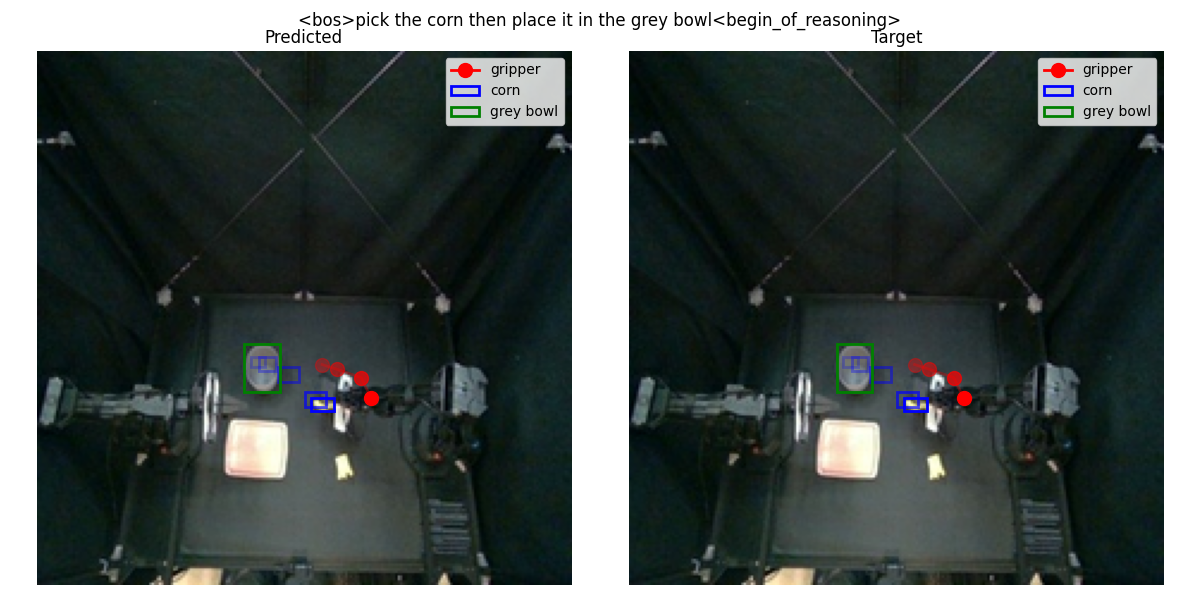

2
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
Error decoding tokens: Decoded DCT coefficients have shape (50, 14), expected (4, 14)
Tokens: [ 405  289 1745  487  377  257  334  348  321  357  309  319 1967  257
  351  283 1708  314  258  535  257  477  273 1711  279  964  392  416
 1219  396]
(224, 224, 3)
(224, 224, 3)
[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


""

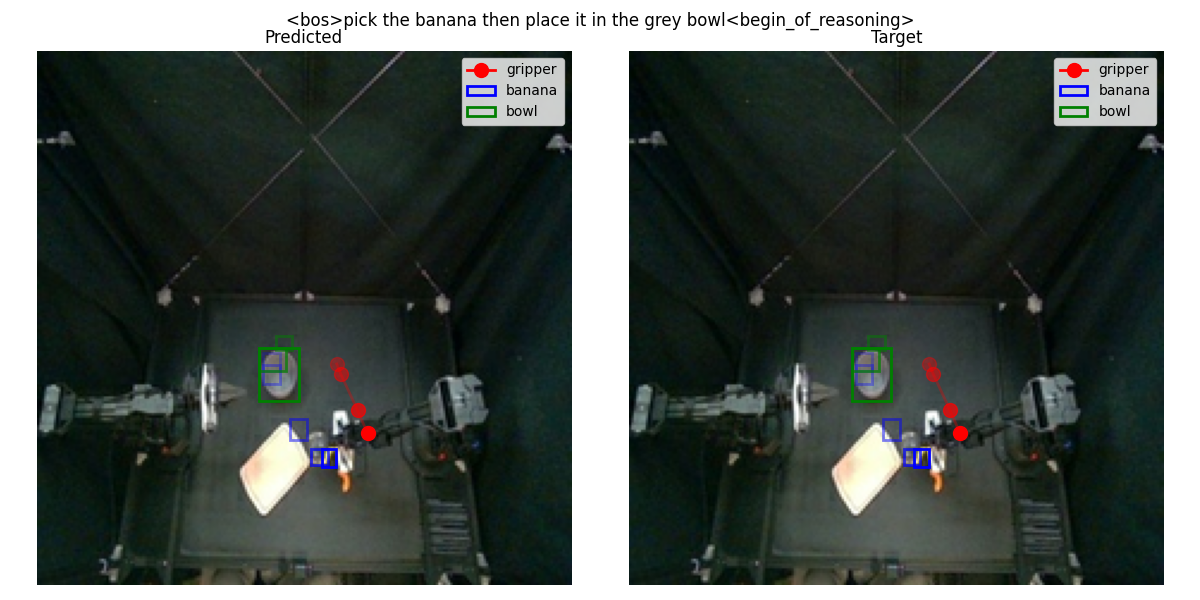

23
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
Error decoding tokens: Decoded DCT coefficients have shape (50, 14), expected (4, 14)
Tokens: [ 422  299  304 1059  583  341  328  364  996  334  273  268  245  665
  291  314  394  274  258  438  310  522 1638  844  525 1040  392  822
  278  834  355  601 1219  257]
(224, 224, 3)
(224, 224, 3)
[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


""

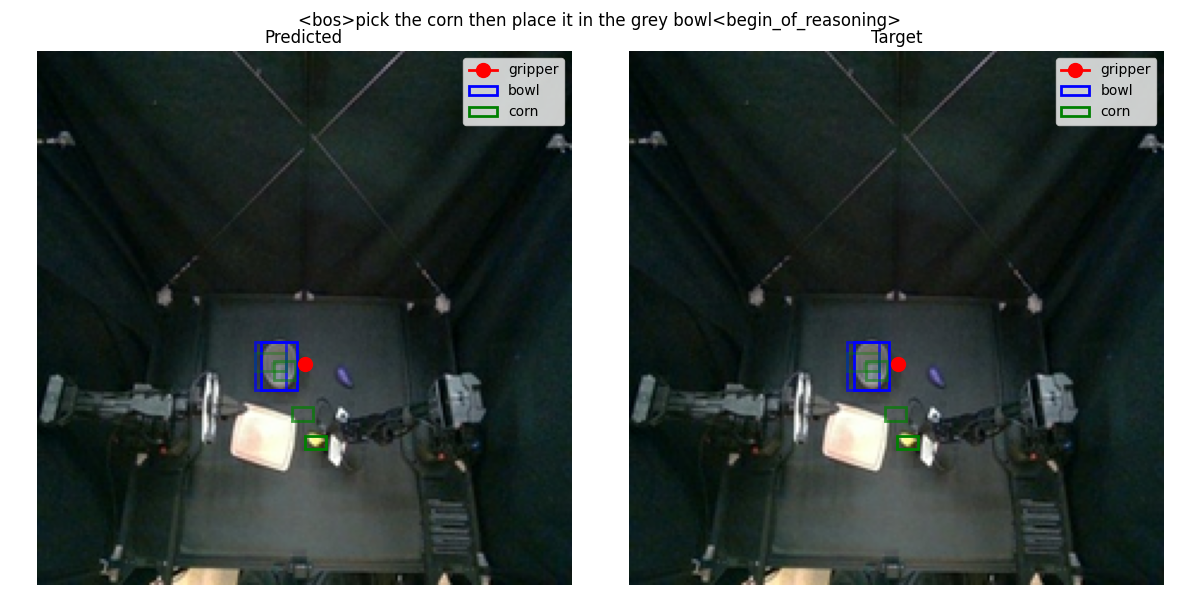

16
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
Error decoding tokens: Decoded DCT coefficients have shape (50, 14), expected (4, 14)
Tokens: [ 372  303  447  412  317  391  266  409 1433  335  495  697  371  291
  292  549  300  978  273  375  641 1016  293  602  524 1612  279  292
  881  326  324 1646  274  681  274  287  353 1245  360  292 1245  416
  456  471  840  342  261  576  312  273  270  349  262  381  305]
(224, 224, 3)
(224, 224, 3)
[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


""

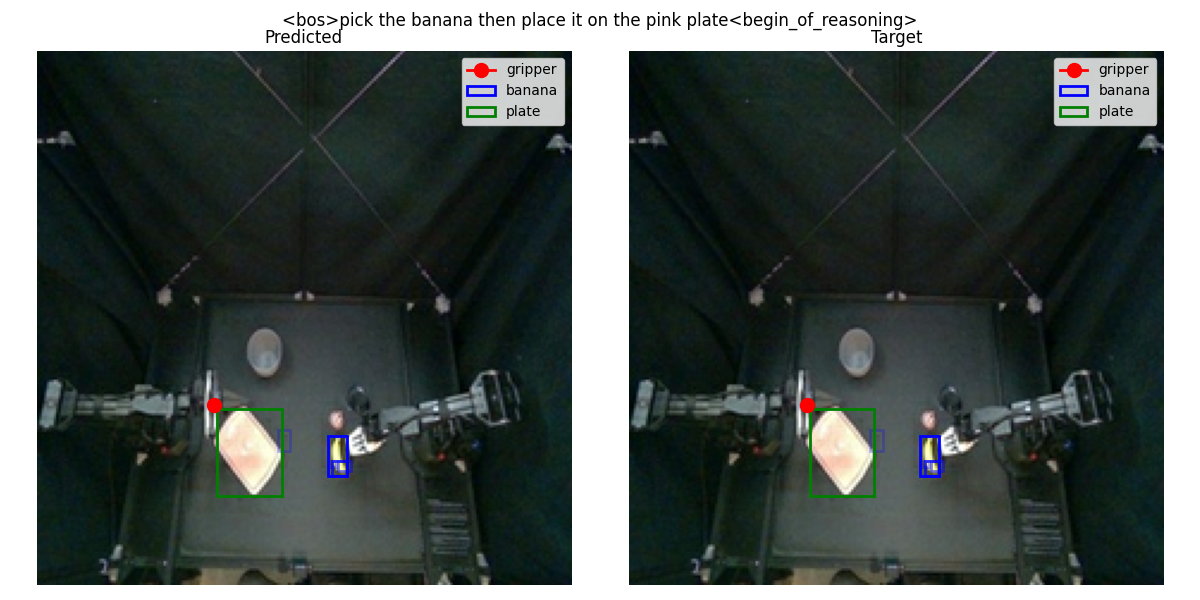

14
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
Error decoding tokens: Decoded DCT coefficients have shape (50, 14), expected (4, 14)
Tokens: [ 370  429  400 1527 1595  398 1788  409  277  372  363  287  582  294
  661  356  286  287  440  333  395  258  727 1704  933  416 1219  315]
(224, 224, 3)
(224, 224, 3)
[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


""

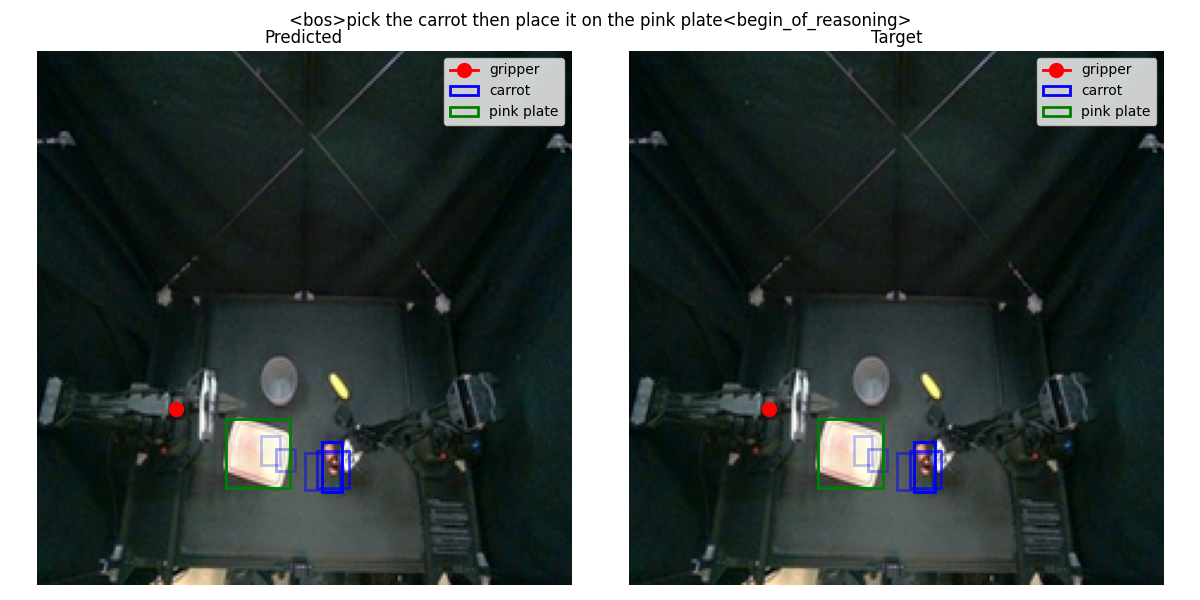

18
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
Error decoding tokens: Decoded DCT coefficients have shape (50, 14), expected (4, 14)
Tokens: [ 364  422  359  376  299  447  266  405  298  664  455  655  357 1009
  292  310  289  885  274 1646  333  283  279  392  292  880  279  395
  483  272  601  822  619  342  456  824  286  456  888  426  456  264
  534  305]
(224, 224, 3)
(224, 224, 3)
[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


""

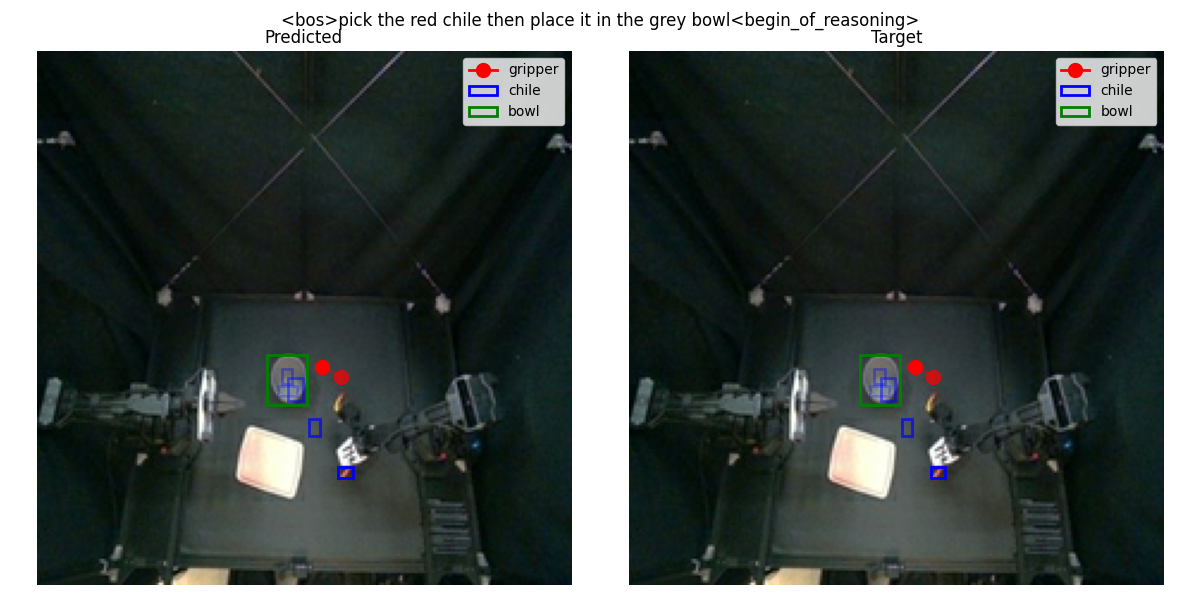

20
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
Error decoding tokens: Decoded DCT coefficients have shape (50, 14), expected (4, 14)
Tokens: [ 418  266  304  319  299  847  376  334  482  317  769  844 1329 1242
  303  733  844  311  442  286  395  380  657  395  515  726  261  349
  456  456  281]
(224, 224, 3)
(224, 224, 3)
[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


""

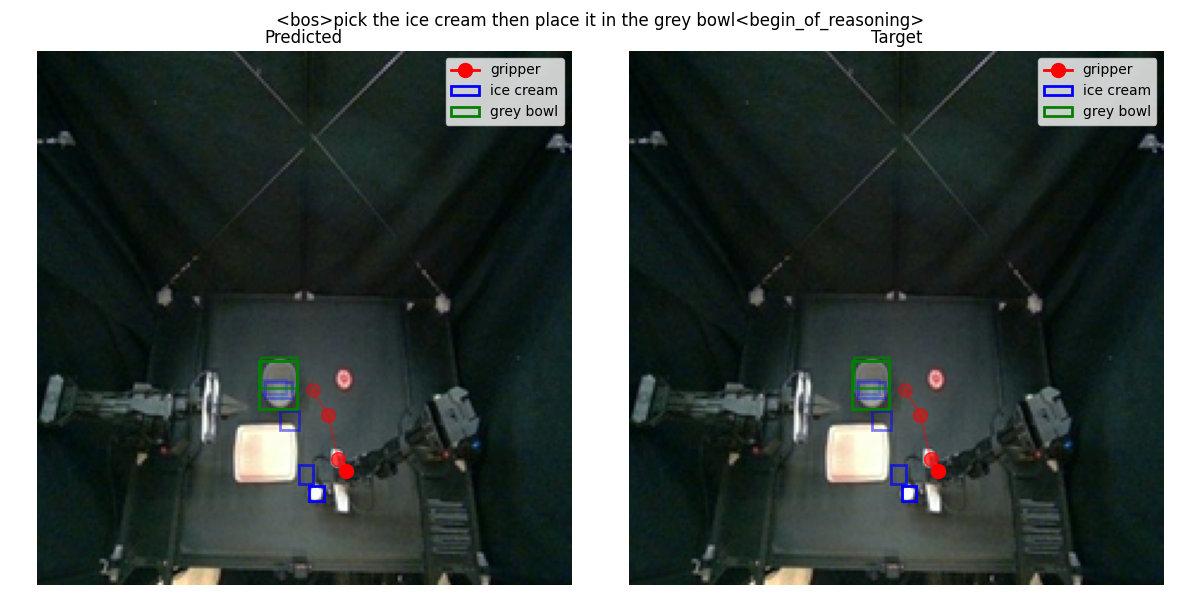

19
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
Error decoding tokens: Decoded DCT coefficients have shape (50, 14), expected (4, 14)
Tokens: [ 409 1311  335  404  429  263  225  319  291  322  557  547  377  266
 1016  310  310 1513 1047  279 1681  273  420  794  286  438  360  340
  286  311  534  311  456  840  456  471  261  350  312  539  343  471
  312  273  342  261  576  456  343  264  276]
(224, 224, 3)
(224, 224, 3)
[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


""

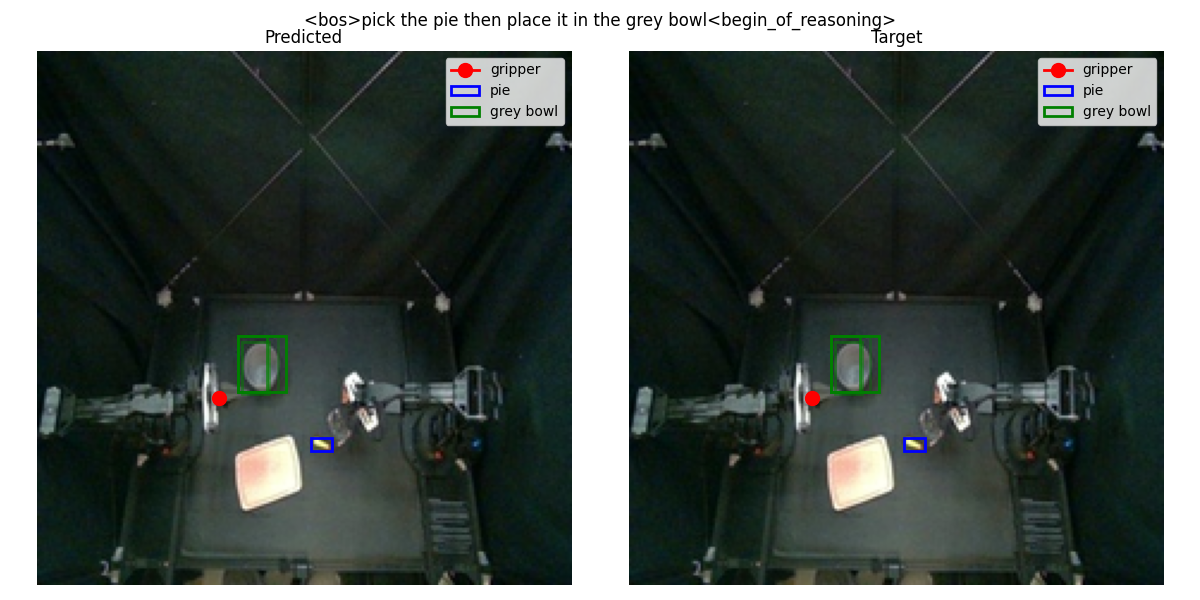

18
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
Error decoding tokens: Decoded DCT coefficients have shape (50, 14), expected (4, 14)
Tokens: [ 364  422  359  376  299  447  266  405  298  664  455  655  357 1009
  292  310  289  885  274 1646  333  283  279  392  292  880  279  395
  483  272  601  822  619  342  456  824  286  456  888  426  456  264
  534  305]
(224, 224, 3)
(224, 224, 3)
[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]]


""

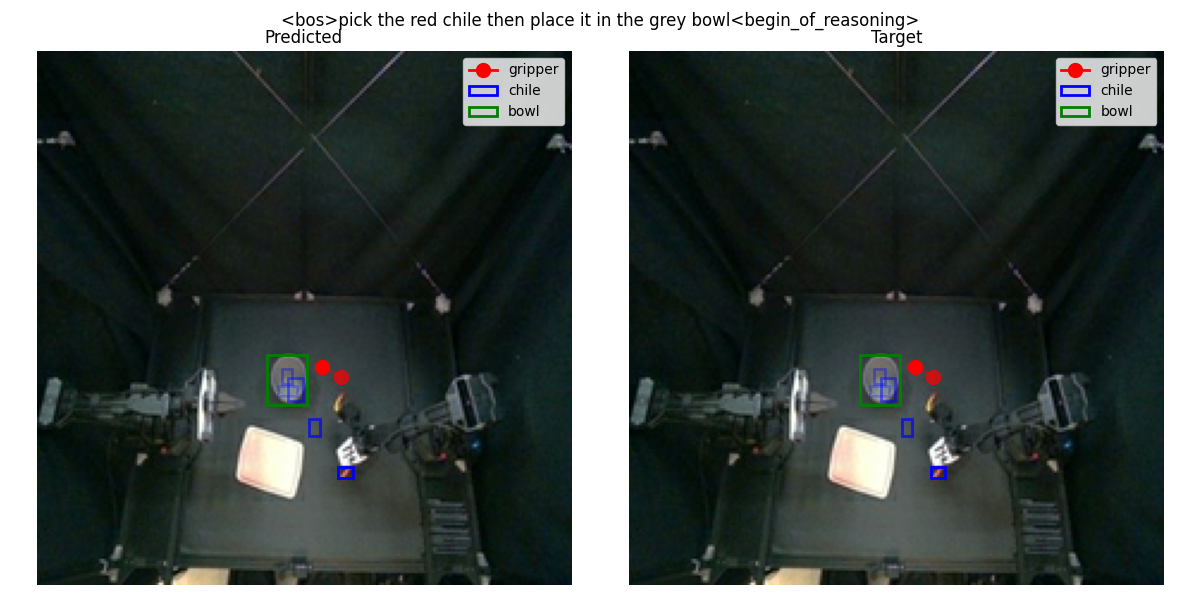

In [19]:
all_actions = []

for _ in range(15):
    num = np.random.randint(0, 25)
    print(num)

    traj = viz_trajectories[num]
    # traj['reasonings'] = np.array(["" for _ in range(len(traj['action']))])

    print(traj['observation'].keys())

    img, action = chain_of_thought(model, traj)
    print(action)
    all_actions.append(action)
    mediapy.show_image(img)

9
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])


/tmp/ipykernel_29157/1321374581.py:48: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  frame = jax.tree_map(lambda x: x[5:6], trajectory)
/tmp/ipykernel_29157/1321374581.py:49: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  frame["observation"] = jax.tree_map(lambda x: x[None], frame["observation"])


(224, 224, 3)
(224, 224, 3)
[[[-0.40401556 -0.84196889 -0.80834327  1.71913275  0.50834327
   -0.34598444  1.05        0.          0.          0.
    0.          0.          0.          0.        ]
  [-0.21882058 -0.91235883  0.16078947  0.4975538  -0.46078947
   -0.23117942  1.05        0.          0.          0.
    0.          0.          0.          0.        ]
  [-0.38117942 -0.58764117 -0.46078947  0.4024462   0.16078947
   -0.06882058  1.05        0.          0.          0.
    0.          0.          0.          0.        ]
  [-0.79598444 -0.05803111 -0.09165673  0.38086725 -0.20834327
    0.04598444  1.05        0.          0.          0.
    0.          0.          0.          0.        ]]]


""

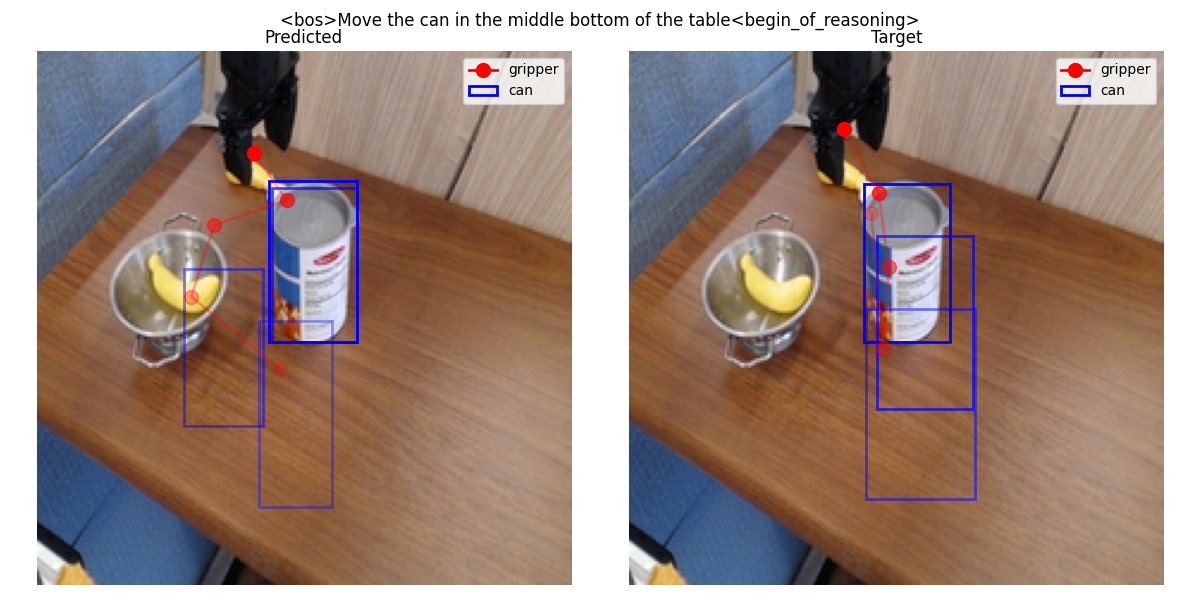

13
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
(224, 224, 3)
(224, 224, 3)
[[[-0.55401556  0.96913275  0.81913275 -0.54196889 -0.58795333
   -0.08212444  1.05        0.          0.          0.
    0.          0.          0.          0.        ]
  [-0.36882058  0.3475538   0.7975538  -0.61235883 -1.14353825
   -1.30056468  1.05        0.          0.          0.
    0.          0.          0.          0.        ]
  [-0.53117942  0.2524462   0.7024462  -0.28764117 -0.65646175
   -2.59943532  1.05        0.          0.          0.
    0.          0.          0.          0.        ]
  [-0.94598444 -0.36913275 -0.51913275  0.24196889  0.58795333
   -3.21787556  1.05        0.          0.          0.
    0.          0.          0.          0.        ]]]


""

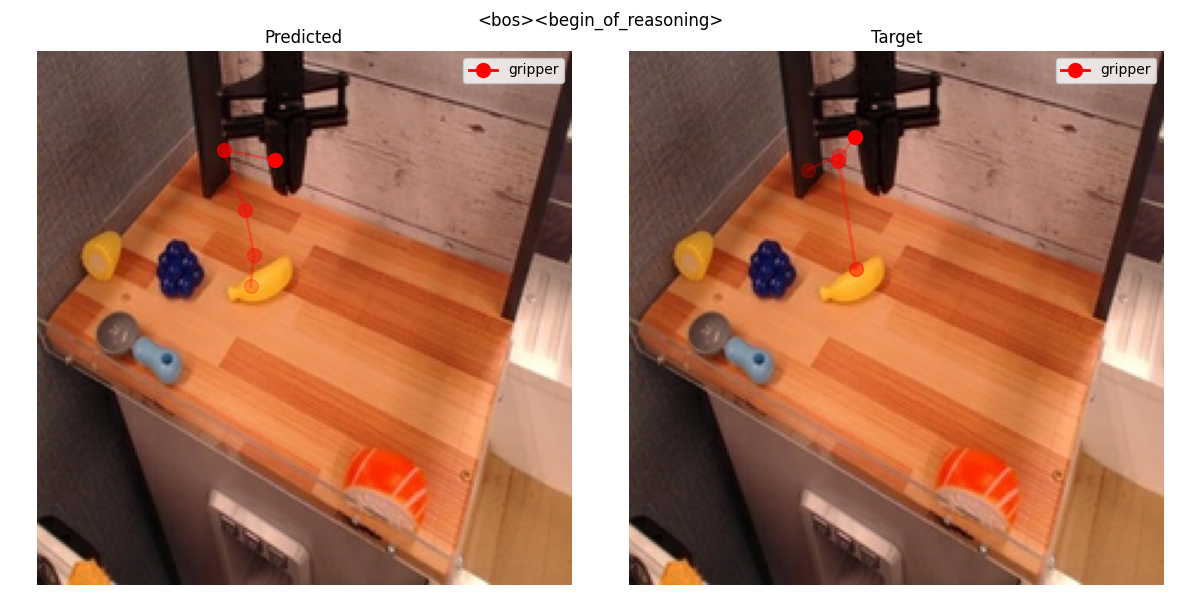

12
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
(224, 224, 3)
(224, 224, 3)
[[[ 1.08393778 -2.16882058  0.54196889 -0.04598444  0.
   -0.80677392  1.05        0.          0.          0.
    0.          0.          0.          0.        ]
  [ 0.32471766 -3.04598444  0.31235883 -0.23117942  0.
   -1.63952269  1.05        0.          0.          0.
    0.          0.          0.          0.        ]
  [-0.32471766 -2.65401556 -0.01235883 -0.06882058  0.
   -0.76047731  1.05        0.          0.          0.
    0.          0.          0.          0.        ]
  [-0.48393778 -2.33117942 -0.24196889  0.34598444  0.
    0.20677392  1.05        0.          0.          0.
    0.          0.          0.          0.        ]]]


""

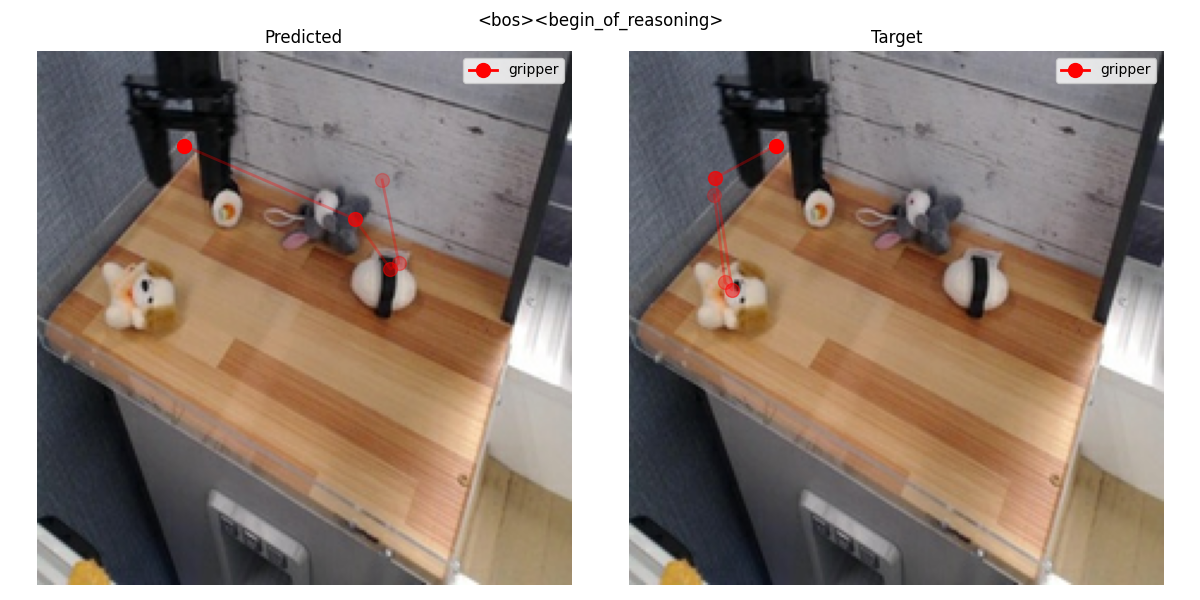

13
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
(224, 224, 3)
(224, 224, 3)
[[[-0.55401556  0.96913275  0.81913275 -0.54196889 -0.58795333
   -0.08212444  1.05        0.          0.          0.
    0.          0.          0.          0.        ]
  [-0.36882058  0.3475538   0.7975538  -0.61235883 -1.14353825
   -1.30056468  1.05        0.          0.          0.
    0.          0.          0.          0.        ]
  [-0.53117942  0.2524462   0.7024462  -0.28764117 -0.65646175
   -2.59943532  1.05        0.          0.          0.
    0.          0.          0.          0.        ]
  [-0.94598444 -0.36913275 -0.51913275  0.24196889  0.58795333
   -3.21787556  1.05        0.          0.          0.
    0.          0.          0.          0.        ]]]


""

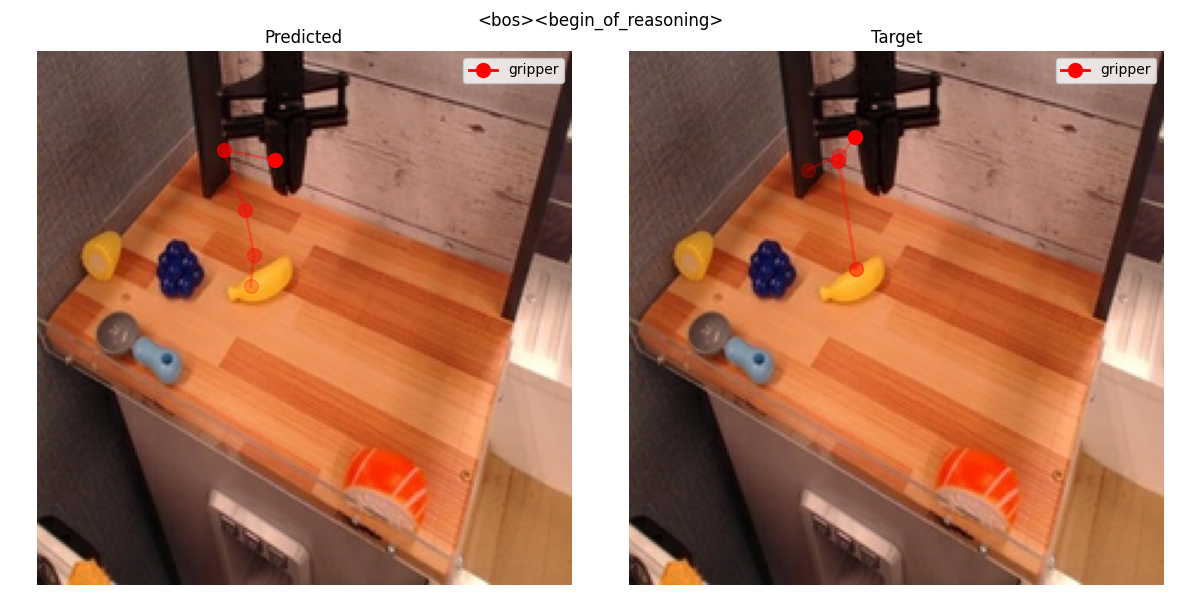

4
dict_keys(['image_primary', 'proprio_bimanual', 'timestep', 'pad_mask_dict', 'timestep_pad_mask', 'task_completed'])
(224, 224, 3)
(224, 224, 3)
[[[ 0.11480503  0.12716386 -0.34598444 -1.90275836  0.58795333
    0.3         1.0731483   0.          0.          0.
    0.          0.          0.          0.        ]
  [ 0.87716386  0.03519497  0.06882058 -1.7207021  -0.05646175
    0.9        -0.03362561  0.          0.          0.
    0.          0.          0.          0.        ]
  [ 0.32283614  0.26480503  0.23117942 -0.6792979  -0.54353825
    0.9         0.03362561  0.          0.          0.
    0.          0.          0.          0.        ]
  [-0.11480503 -0.42716386  0.04598444 -0.49724164 -0.58795333
    0.3         0.1268517   0.          0.          0.
    0.          0.          0.          0.        ]]]


""

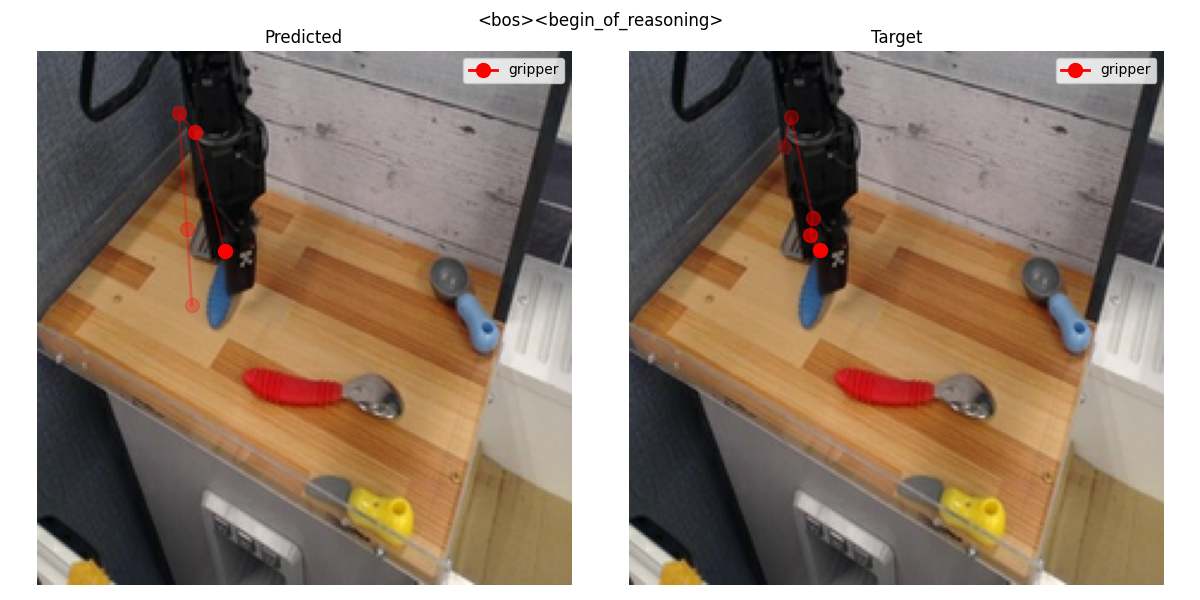

In [18]:
all_actions = []

for _ in range(1):
    num = np.random.randint(0, 25)
    print(num)

    traj = viz_trajectories[num]
    # traj['reasonings'] = np.array(["" for _ in range(len(traj['action']))])

    print(traj['observation'].keys())

    img, action = chain_of_thought(model, traj)
    print(action)
    all_actions.append(action)
    mediapy.show_image(img)

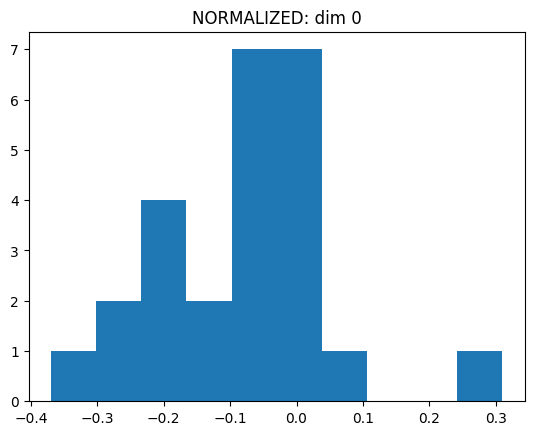

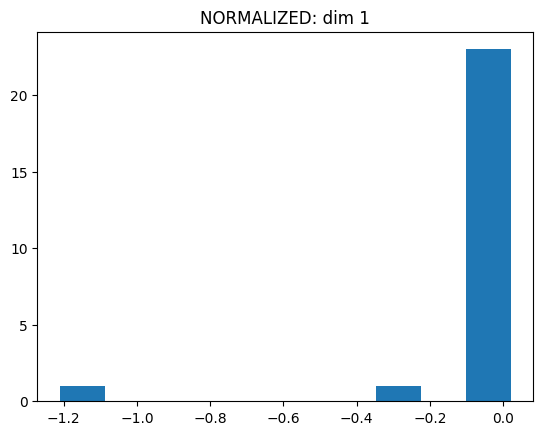

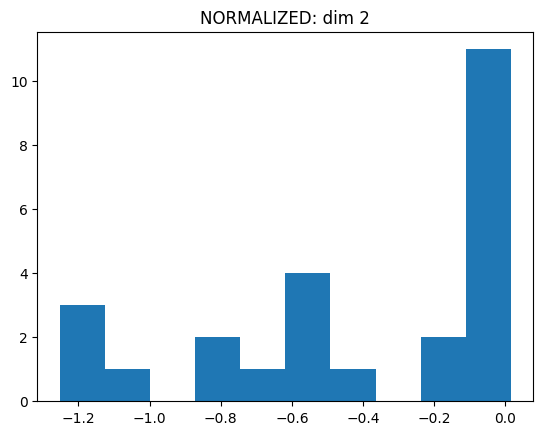

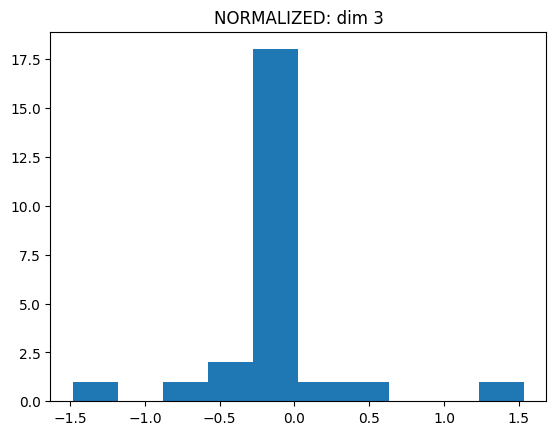

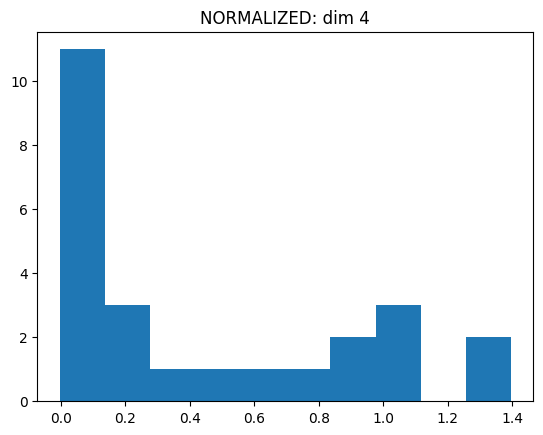

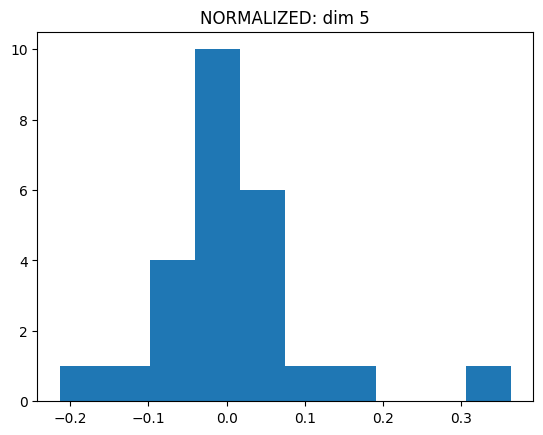

In [16]:
all_actions = np.array(all_actions).squeeze()
# plot the distribution for each action dim 

import matplotlib.pyplot as plt 
for i in range(6):
    plt.hist(all_actions[:, i], bins=10) # data is your numerical data, bins is the number of intervals
    plt.title(f"NORMALIZED: dim {i}")
    plt.show()

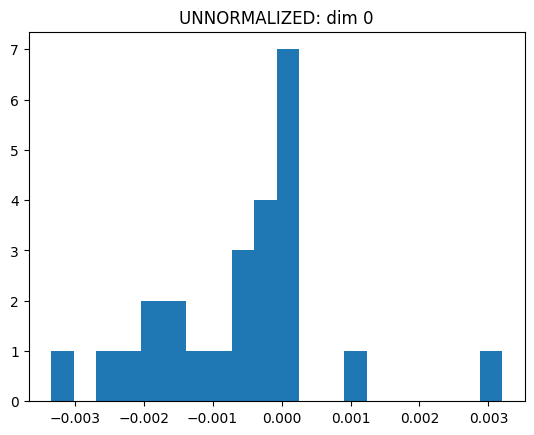

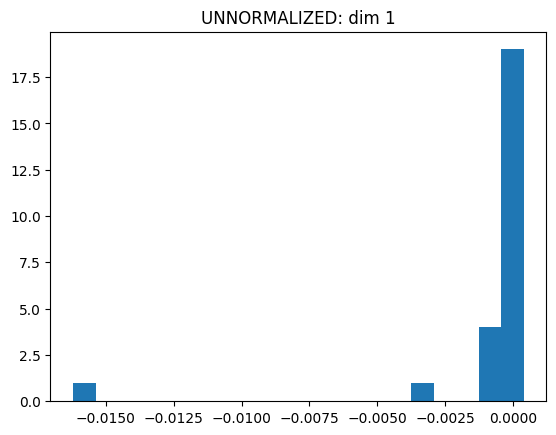

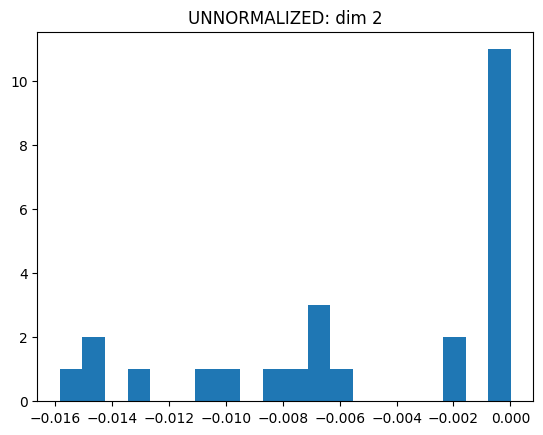

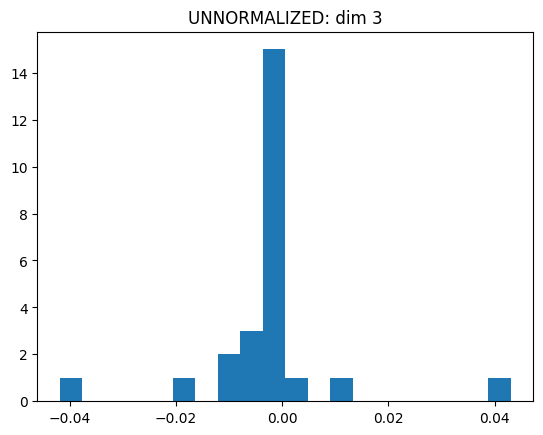

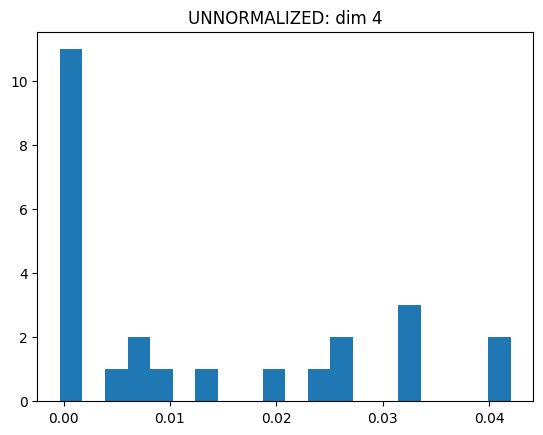

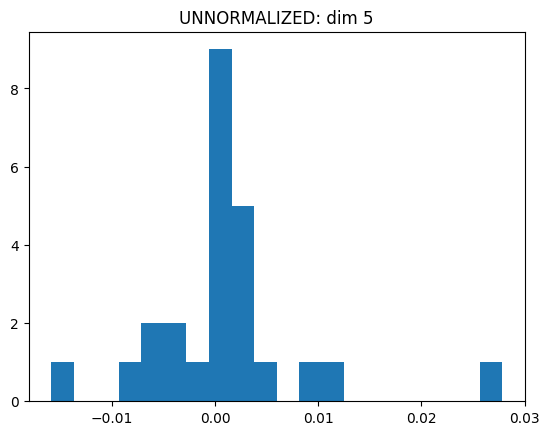

: 

In [19]:
DATASET_MEAN = [0.000217586566577665, 0.000125082762679085, -0.000171084306202828, -0.000161708827363327, -0.000252487370744347, 0.00025158081552945, 0.587948560714722]
DATASET_STD = [0.00963237509131432, 0.013500677421689, 0.0125105613842607, 0.0281452126801014, 0.0302824676036835, 0.0758553743362427, 0.487718880176544]

for i in range(6):
    plt.hist(DATASET_MEAN[i] + DATASET_STD[i] * all_actions[:, i], bins=20) # data is your numerical data, bins is the number of intervals
    plt.title(f"UNNORMALIZED: dim {i}")
    plt.show()

In [1]:
from octo.data.oxe import make_oxe_dataset_kwargs
from octo.data.dataset import make_single_dataset

dataset_name = "aloha_pen_uncap_diverse_dataset"
dataset_kwargs = make_oxe_dataset_kwargs(dataset_name,"gs://rail-orca-central2/resize_256_256")
dataset = make_single_dataset(
                                dataset_kwargs, 
                                frame_transform_kwargs=dict(
                                    resize_size={"primary": (256, 256)},
                                ),
                                train=True)
iterator = dataset.iterator()
num_trajs = len([1 for traj in iterator])

2025-03-20 22:54:51.652768: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-20 22:54:51.656043: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-20 22:54:51.666691: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742511291.684981  611338 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742511291.690488  611338 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1742511291.704043  611338 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

AttributeError: module 'ml_dtypes' has no attribute 'float4_e2m1fn'
Cause: Unable to locate the source code of <function _gcd_import at 0x7fedf7583d80>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: Unable to locate the source code of <function _gcd_import at 0x7fedf7583d80>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: Unable to locate the source code of <function _gcd_import at 0x7fedf7583d80>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2025-03-20 22:54:57.192899: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
97it [00:49,  2.47it/s]2025-03-20 22:55:46.655638: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
97it [00:49,  1.96it/s]
2025-03-20 22:56:28.847075: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [2]:
num_trajs

92